#  スクレイピング（from netkeiba）

## ---関数定義---

In [3]:
import pandas as pd
import numpy as np
from tqdm import tqdm_notebook as tqdm
import time
import requests
import re
from bs4 import BeautifulSoup
from urllib.request import urlopen
from tqdm.notebook import tqdm as tqdm #プログレスバーを表示するための設定

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.options import Options
from time import sleep
import chromedriver_binary

race idのルールをメモ

In [4]:
#エラー処理用
# 01:札幌、０２：函館、０３：福島、０４：新潟、０５：東京、０６：中山、０７：中京、０８：京都、０９：阪神、１０：小倉
# race_id 201905021211 --> 2019年＋東京＋2回＋12日目＋１１R

### データ取得前の下準備

In [6]:
def race_table_tanfuku(race_id, no):
    options = webdriver.ChromeOptions()
    options.add_argument("--headless")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")

    driver = webdriver.Chrome("chromedriver", options=options)
    driver.implicitly_wait(10)  #ページの読み込みが完了するまでx秒待機
    driver.get("https://race.netkeiba.com/odds/index.html?type=b1&race_id=" + race_id + "&rf=shutuba_submenu")

    html = driver.page_source.encode("utf-8")
    table_data_1 = pd.read_html(html, encoding="utf-8", skiprows=0, header=0)
    
    if no==0:
        #単勝
        table_data_2 = table_data_1[0].drop(['印','選択'], axis = 1)
    else:
        #複勝
        table_data_2 = table_data_1[1].drop(['印','選択'], axis = 1)
    
    return table_data_2


def race_table_uwsnpt(race_id, type):
    options = webdriver.ChromeOptions()
    options.add_argument("--headless")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")

    driver = webdriver.Chrome("chromedriver", options=options)
    driver.implicitly_wait(10)  #ページの読み込みが完了するまでx秒待機
    driver.get("https://race.netkeiba.com/odds/index.html?type=" + type + "&race_id=" + race_id + "&housiki=c99")

    html = driver.page_source.encode("utf-8")
    table_data_1 = pd.read_html(html, encoding="utf-8", skiprows=0, header=0)
    
    table_data_2 = table_data_1[0]
    
    return table_data_2

## 単勝

In [7]:
# 対象レース
#     ★オッズ重複あり
#         ヴィクトリアマイル：　'202205020811' 
#         5/15 中京1R ３歳未勝利：'202207030401'

#     ★除外によりオッズなしが含まれる
#         オークス：　'202205021011'　
#         青葉賞： '202205020311'

#    ★小頭数
#         '202205021107'

#     通常
#         ダービー: '202205021211'

In [8]:
#データの取り出し
race_id = '202205021211'
race_t = race_table_tanfuku(race_id, 0)

In [40]:
#オッズがない馬を削除（エラーになるため。除外などではある処理）
race_table = race_t[race_t['オッズ'] != '---.-'].reset_index()
race_table['オッズ'] = pd.to_numeric(race_table['オッズ'], errors='coerce')

#クレンジング（オッズランクの生成処理）
race_table['単勝オッズランク'] = race_table['オッズ'].rank(method='first').astype('int')
#race_table

In [42]:
#クレンジング(必要データの追加_（2）)
number_of_horse = len(race_table)  #出走馬の頭数（後で出走表からとる）
race_table['穴馬フラグ_単勝']= 0.0 #オッズ断層列を追加


for i in range(number_of_horse):
    
    ####対象オッズランク馬
    ch_odds_rank = race_table.at[i, '単勝オッズランク']
    ch_odds = race_table.at[i, 'オッズ']

    
    ####次のオッズランク馬
    if ch_odds_rank != number_of_horce:
        nx_odds = race_table[race_table.単勝オッズランク == ch_odds_rank + 1]['オッズ'].values
        nx_odds_rank = race_table[race_table.単勝オッズランク == ch_odds_rank + 1]['単勝オッズランク'].values
            
    else:
        nx_odds_rank = ch_odds_rank
        nx_odds = ch_odds
    

    ####アウトプット
    odds_danso = nx_odds / ch_odds
    TS = 1.7
    
    if odds_danso > TS*2:
        race_table.at[i, '穴馬フラグ_単勝'] = 2.0
    elif odds_danso <= TS*2 and odds_danso > TS:
        race_table.at[i, '穴馬フラグ_単勝'] = 1.0
    else:
        race_table.at[i, '穴馬フラグ_単勝'] = 0.0

race_table

,index,枠,馬番,馬名,オッズ,単勝オッズランク,穴馬フラグ_単勝
0,0,1,1,アスクワイルドモア,60.3,13,0.0
1,1,1,2,セイウンハーデス,150.0,16,0.0
2,2,2,3,アスクビクターモア,24.7,7,0.0
3,3,2,4,マテンロウレオ,198.7,18,0.0
4,4,3,5,ピースオブエイト,59.4,12,0.0
5,5,3,6,プラダリア,20.7,5,0.0
6,6,4,7,オニャンコポン,24.2,6,0.0
7,7,4,8,ビーアストニッシド,182.3,17,0.0
8,8,5,9,ジャスティンパレス,43.1,10,0.0
9,9,5,10,マテンロウオリオン,40.6,9,0.0


### 馬連

In [11]:
def race_table_uwsnpt(race_id, type):
    options = webdriver.ChromeOptions()
    options.add_argument("--headless")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")

    driver = webdriver.Chrome("chromedriver", options=options)
    driver.implicitly_wait(10)  #ページの読み込みが完了するまでx秒待機
    driver.get("https://race.netkeiba.com/odds/index.html?type=" + type + "&race_id=" + race_id + "&housiki=c99")

    html = driver.page_source.encode("utf-8")
    table_data_1 = pd.read_html(html, encoding="utf-8", skiprows=0, header=0)
    
    table_data_2 = table_data_1[0]
    
    return table_data_2

##### 馬連①

In [104]:
#データ抽出
#race_id = '202205020811'
race_type = 'b4'

race_ur = race_table_uwsnpt(race_id, race_type)
race_ur_table = race_ur.drop(['人気', '選択', '組み合わせ'], axis = 1)
race_ur_table['オッズ'] = pd.to_numeric(race_ur_table['オッズ'], errors='coerce')
race_ur_table = race_ur_table[race_ur_table['1頭目'] != '馬番']
#race_ur_table

In [155]:
#######################
###馬連の上位人気リスト
#######################

race_ur_table_fil = race_ur_table[race_ur_table['オッズ']<=100]

race_ur_table_1 = race_ur_table_fil.drop(['2頭目', '2頭目.1'], axis = 1)
race_ur_table_1 = race_ur_table_1.rename(columns={'1頭目': '馬番', '1頭目.1': '馬名'})

race_ur_table_2 = race_ur_table_fil.drop(['1頭目', '1頭目.1'], axis = 1)
race_ur_table_2 = race_ur_table_2.rename(columns={'2頭目': '馬番', '2頭目.1': '馬名'})

race_ur_table_con_1 = pd.concat([race_ur_table_1, race_ur_table_2], axis=0)
race_ur_table_con_1 = race_ur_table_con_1.sort_values(['オッズ'], ascending = True).reset_index()


#集計
race_ur_count_1 = race_ur_table_con_1.groupby(['馬番', '馬名']).size().reset_index()
race_ur_count_1.columns = ['馬番', '馬名','count']
race_ur_count_1['ratio'] = 100 * race_ur_count_1['count']/ race_ur_count_1['count'].sum() 
race_ur_count_1 = race_ur_count_1.sort_values(['count'], ascending=False).reset_index()


#馬連オッズランク
number_of_horse = len(race_ur_count_1)

for i in range(number_of_horse):
    ratio = race_ur_count_1.at[i, 'ratio']

    if ratio>10.0:
        race_ur_count_1.at[i, '馬連12ランク'] = 2.0
    elif ratio<=10.0 and ratio>7.5:
        race_ur_count_1.at[i, '馬連12ランク'] = 1.0
    else:
        race_ur_count_1.at[i, '馬連12ランク'] = 0.0

#race_ur_count_1



#race_tableへマージ
race_table = pd.merge(race_table[['枠', '馬番', '馬名', 'オッズ', '単勝オッズランク', '穴馬フラグ_単勝']], race_ur_count_1[['馬名', '馬連12ランク']], on='馬名', how='left')
race_table = race_table.fillna(0)
race_table


,枠,馬番,馬名,オッズ,単勝オッズランク,穴馬フラグ_単勝,馬連12ランク
0,1,1,アスクワイルドモア,60.3,13,0.0,0.0
1,1,2,セイウンハーデス,150.0,16,0.0,0.0
2,2,3,アスクビクターモア,24.7,7,0.0,1.0
3,2,4,マテンロウレオ,198.7,18,0.0,0.0
4,3,5,ピースオブエイト,59.4,12,0.0,0.0
5,3,6,プラダリア,20.7,5,0.0,1.0
6,4,7,オニャンコポン,24.2,6,0.0,0.0
7,4,8,ビーアストニッシド,182.3,17,0.0,0.0
8,5,9,ジャスティンパレス,43.1,10,0.0,0.0
9,5,10,マテンロウオリオン,40.6,9,0.0,0.0


##### 馬連②

In [144]:
race_ur_table_fil = race_ur_table

#単勝１番人気の馬番
ichi_nin = race_table[race_table['単勝オッズランク']==1]['馬番'].values[0]
ichi_name = race_table[race_table['単勝オッズランク']==1]['馬名'].values[0]


print('一番人気　：　', ichi_nin, '番', ichi_name)
print('　　　')
print('↓↓↓↓一番人気 「', ichi_nin, '番', ichi_name, '」 から流したオッズランク↓↓↓↓')

#一番人気からの流したリスト
race_ur_table_1 = race_ur_table_fil[race_ur_table_fil['2頭目'] == str(ichi_nin)]
race_ur_table_1 = race_ur_table_1.drop(['2頭目', '2頭目.1'], axis = 1)
race_ur_table_1 = race_ur_table_1.rename(columns={'1頭目': '馬番', '1頭目.1': '馬名'})

race_ur_table_2 = race_ur_table_fil[race_ur_table_fil['1頭目'] == str(ichi_nin)]
race_ur_table_2 = race_ur_table_2.drop(['1頭目', '1頭目.1'], axis = 1)
race_ur_table_2 = race_ur_table_2.rename(columns={'2頭目': '馬番', '2頭目.1': '馬名'})

race_ur_table_con_2 = pd.concat([race_ur_table_1, race_ur_table_2], axis=0)
race_ur_table_con_2 = race_ur_table_con_2.sort_values(['オッズ'], ascending = True).reset_index()


#馬番オッズランク設定
race_ur_table_con_2['馬連オッズランク'] = race_ur_table_con_2['オッズ'].rank(method='first').astype('int') + 1
#race_ur_table_con_2


一番人気　：　 12 番 ダノンベルーガ
　　　
↓↓↓↓一番人気 「 12 番 ダノンベルーガ 」 から流したオッズランク↓↓↓↓


,index,オッズ,馬番,馬名,馬連オッズランク
0,1,5.6,18,イクイノックス,2
1,2,7.1,13,ドウデュース,3
2,6,13.8,15,ジオグリフ,4
3,9,38.1,6,プラダリア,5
4,10,38.2,3,アスクビクターモア,6
5,15,78.6,7,オニャンコポン,7
6,17,82.7,10,マテンロウオリオン,8
7,22,91.3,16,キラーアビリティ,9
8,26,103.8,9,ジャスティンパレス,10
9,33,136.1,17,ロードレゼル,11


In [145]:
#クレンジング(必要データの追加_（2）)
number_of_horse = len(race_ur_table_con_2)  #出走馬の頭数（後で出走表からとる）
race_ur_table_con_2['穴馬フラグ_馬連']= 0.0 #オッズ断層列を追加


for i in range(number_of_horse):
    
    ####対象オッズランク馬
    ch_odds_rank = race_ur_table_con_2.at[i, '馬連オッズランク']
    ch_odds = race_ur_table_con_2.at[i, 'オッズ']

    
    ####次のオッズランク馬
    if ch_odds_rank != number_of_horce:
        nx_odds = race_ur_table_con_2[race_ur_table_con_2.馬連オッズランク == ch_odds_rank + 1]['オッズ'].values
        nx_odds_rank = race_ur_table_con_2[race_ur_table_con_2.馬連オッズランク == ch_odds_rank + 1]['馬連オッズランク'].values
            
    else:
        nx_odds_rank = ch_odds_rank
        nx_odds = ch_odds
    

    ####アウトプット
    odds_danso = nx_odds / ch_odds
    US = 1.7
    
    if odds_danso > US*2:
        race_ur_table_con_2.at[i, '穴馬フラグ_馬連'] = 2.0
    elif odds_danso <= US*2 and odds_danso > US:
        race_ur_table_con_2.at[i, '穴馬フラグ_馬連'] = 1.0
    else:
        race_ur_table_con_2.at[i, '穴馬フラグ_馬連'] = 0.0

race_ur_table_con_2

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:27: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:29: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.


,index,オッズ,馬番,馬名,馬連オッズランク,穴馬フラグ_馬連
0,1,5.6,18,イクイノックス,2,0.0
1,2,7.1,13,ドウデュース,3,1.0
2,6,13.8,15,ジオグリフ,4,1.0
3,9,38.1,6,プラダリア,5,0.0
4,10,38.2,3,アスクビクターモア,6,1.0
5,15,78.6,7,オニャンコポン,7,0.0
6,17,82.7,10,マテンロウオリオン,8,0.0
7,22,91.3,16,キラーアビリティ,9,0.0
8,26,103.8,9,ジャスティンパレス,10,0.0
9,33,136.1,17,ロードレゼル,11,0.0


In [146]:
#馬連オッズランクをベースに、単勝オッズランクを比較
race_ur_table_con_2 = \
pd.merge(race_ur_table_con_2[['馬番', '馬名', 'オッズ', '馬連オッズランク', '穴馬フラグ_馬連']], race_table[['馬名', '単勝オッズランク']], on='馬名', how='left')

#穴馬フラグ
race_ur_table_con_2['穴馬フラグ_馬連単勝'] = (race_ur_table_con_2['馬連オッズランク'] - race_ur_table_con_2['単勝オッズランク']) * 1.0

for i in range(number_of_horse):
    odds_ur_rank = race_ur_table_con_2.at[i, '穴馬フラグ_馬連単勝']

    if odds_ur_rank > 5.0:
        race_ur_table_con_2.at[i, '穴馬フラグ_馬連単勝'] = 2.0
    elif odds_ur_rank <= 5.0 and odds_ur_rank > 3.0:
        race_ur_table_con_2.at[i, '穴馬フラグ_馬連単勝'] = 1.0
    elif odds_ur_rank <= 3.0 and odds_ur_rank > 1.0:
        race_ur_table_con_2.at[i, '穴馬フラグ_馬連単勝'] = 0.5
    else:
        race_ur_table_con_2.at[i, '穴馬フラグ_馬連単勝'] = 0.0
    

race_ur_table_con_2


,馬番,馬名,オッズ,馬連オッズランク,穴馬フラグ_馬連,単勝オッズランク,穴馬フラグ_馬連単勝
0,18,イクイノックス,5.6,2,0.0,2,0.0
1,13,ドウデュース,7.1,3,1.0,3,0.0
2,15,ジオグリフ,13.8,4,1.0,4,0.0
3,6,プラダリア,38.1,5,0.0,5,0.0
4,3,アスクビクターモア,38.2,6,1.0,7,0.0
5,7,オニャンコポン,78.6,7,0.0,6,0.0
6,10,マテンロウオリオン,82.7,8,0.0,9,0.0
7,16,キラーアビリティ,91.3,9,0.0,8,0.0
8,9,ジャスティンパレス,103.8,10,0.0,10,0.0
9,17,ロードレゼル,136.1,11,0.0,11,0.0


In [157]:
#race_tableへマージ
race_table = pd.merge(race_table[['枠', '馬番', '馬名', 'オッズ', '単勝オッズランク', '穴馬フラグ_単勝', '馬連12ランク']], \
                      race_ur_table_con_2[['馬名', '穴馬フラグ_馬連', '穴馬フラグ_馬連単勝']], \
                      on='馬名', how='left')
race_table = race_table.fillna(0)
race_table

,枠,馬番,馬名,オッズ,単勝オッズランク,穴馬フラグ_単勝,馬連12ランク,穴馬フラグ_馬連,穴馬フラグ_馬連単勝
0,1,1,アスクワイルドモア,60.3,13,0.0,0.0,1.0,0.0
1,1,2,セイウンハーデス,150.0,16,0.0,0.0,0.0,0.0
2,2,3,アスクビクターモア,24.7,7,0.0,1.0,1.0,0.0
3,2,4,マテンロウレオ,198.7,18,0.0,0.0,0.0,0.0
4,3,5,ピースオブエイト,59.4,12,0.0,0.0,0.0,0.0
5,3,6,プラダリア,20.7,5,0.0,1.0,0.0,0.0
6,4,7,オニャンコポン,24.2,6,0.0,0.0,0.0,0.0
7,4,8,ビーアストニッシド,182.3,17,0.0,0.0,0.0,0.0
8,5,9,ジャスティンパレス,43.1,10,0.0,0.0,0.0,0.0
9,5,10,マテンロウオリオン,40.6,9,0.0,0.0,0.0,0.0


### ワイド

In [201]:
#データ抽出
#race_id = '202205020811'
race_type = 'b5'

race_wide = race_table_uwsnpt(race_id, race_type)
race_wide_table = race_wide.drop(['人気', '選択', '組み合わせ'], axis = 1)
# race_wide_table['オッズ'] = pd.to_numeric(race_wide_table['オッズ'], errors='coerce')
race_wide_table = race_wide_table[race_wide_table['1頭目'] != '馬番']
race_wide_table[['オッズ_1','オッズ_2']] = race_wide_table.オッズ.str.split(pat=' ', expand=True)
race_wide_table = race_wide_table.drop(['オッズ', 'オッズ_2'], axis = 1)
race_wide_table = race_wide_table.rename(columns={'オッズ_1':'オッズ'})
race_wide_table['オッズ'] = pd.to_numeric(race_wide_table['オッズ'], errors='coerce')
# race_wide_table = race_wide_table..reindex(columns=['a','f','d','b','c','e'])
race_wide_table

,1頭目,1頭目.1,2頭目,2頭目.1,オッズ
1,12,ダノンベルーガ,18,イクイノックス,2.5
2,13,ドウデュース,18,イクイノックス,3.0
3,12,ダノンベルーガ,13,ドウデュース,3.3
4,15,ジオグリフ,18,イクイノックス,4.3
5,13,ドウデュース,15,ジオグリフ,4.7
...,...,...,...,...,...
96,4,マテンロウレオ,15,ジオグリフ,212.6
97,9,ジャスティンパレス,11,ジャスティンロック,217.6
98,10,マテンロウオリオン,11,ジャスティンロック,220.0
99,5,ピースオブエイト,7,オニャンコポン,220.4


In [212]:
#######################
###ワイドの上位人気リスト
#######################

race_wide_table_fil = race_wide_table[race_wide_table['オッズ']<=30]

race_wide_table_1 = race_wide_table_fil.drop(['2頭目', '2頭目.1'], axis = 1)
race_wide_table_1 = race_wide_table_1.rename(columns={'1頭目': '馬番', '1頭目.1': '馬名'})

race_wide_table_2 = race_wide_table_fil.drop(['1頭目', '1頭目.1'], axis = 1)
race_wide_table_2 = race_wide_table_2.rename(columns={'2頭目': '馬番', '2頭目.1': '馬名'})

race_wide_table_con_1 = pd.concat([race_wide_table_1, race_wide_table_2], axis=0)
race_wide_table_con_1 = race_wide_table_con_1.sort_values(['オッズ'], ascending = True).reset_index()

#race_wide_table_con_1

In [213]:
#集計（どの馬が上位人気でよく買われているか）
race_wide_count = race_wide_table_con_1.groupby(['馬番', '馬名']).size().reset_index()
race_wide_count.columns = ['馬番', '馬名','count']
race_wide_count['ratio'] = 100 * race_wide_count['count']/ race_wide_count['count'].sum() 
race_wide_count.sort_values(['count'], ascending=False).reset_index()


#ワイド23フラグ付
#５以上はつける

,index,馬番,馬名,count,ratio
0,6,18,イクイノックス,10,18.518519
1,1,12,ダノンベルーガ,9,16.666667
2,2,13,ドウデュース,9,16.666667
3,3,15,ジオグリフ,5,9.259259
4,7,3,アスクビクターモア,4,7.407407
5,8,6,プラダリア,4,7.407407
6,0,10,マテンロウオリオン,3,5.555556
7,4,16,キラーアビリティ,3,5.555556
8,9,7,オニャンコポン,3,5.555556
9,10,9,ジャスティンパレス,3,5.555556


### 三連複

In [26]:
#データ抽出
#race_id = '202205020811'
race_type = 'b7'

race_sp = race_table_uwsnpt(race_id, race_type)
race_sp_table = race_sp.drop(['人気', '選択', '組み合わせ'], axis = 1)
race_sp_table['オッズ'] = pd.to_numeric(race_sp_table['オッズ'], errors='coerce')
race_sp_table = race_sp_table[race_sp_table['オッズ'] != 'オッズ']
#race_sp_table

In [28]:
#対象を80倍以下にする
race_sp_table_fil = race_sp_table[race_sp_table['オッズ']<=80]

#三連単の1〜3着を縦に積み上げる
race_sp_table_1 = race_sp_table_fil.drop(['2頭目', '2頭目.1', '3頭目', '3頭目.1'], axis = 1)
race_sp_table_1 = race_sp_table_1.rename(columns={'1頭目': '馬番', '1頭目.1': '馬名'})
race_sp_table_2 = race_sp_table_fil.drop(['1頭目', '1頭目.1', '3頭目', '3頭目.1'], axis = 1)
race_sp_table_2 = race_sp_table_2.rename(columns={'2頭目': '馬番', '2頭目.1': '馬名'})
race_sp_table_3 = race_sp_table_fil.drop(['1頭目', '1頭目.1', '2頭目', '2頭目.1'], axis = 1)
race_sp_table_3 = race_sp_table_3.rename(columns={'3頭目': '馬番', '3頭目.1': '馬名'})

race_sp_table_con = pd.concat([race_sp_table_1, race_sp_table_2, race_sp_table_3], axis=0)
#race_sp_table_con

In [29]:
#集計（どの馬が上位人気でよく買われているか）
race_sp_count = race_sp_table_con.groupby(['馬番', '馬名']).size().reset_index()
race_sp_count.columns = ['馬番', '馬名','count']
race_sp_count['ratio'] = 100 * race_sp_count['count']/ race_sp_count['count'].sum() 
race_sp_count.sort_values(['count'], ascending=False).reset_index()

#40％以上は軸確定
#20％以上は軸・対抗になり得る

,index,馬番,馬名,count,ratio
0,0,12,ダノンベルーガ,9,18.75
1,1,13,ドウデュース,9,18.75
2,2,15,ジオグリフ,9,18.75
3,3,18,イクイノックス,9,18.75
4,4,3,アスクビクターモア,6,12.50
5,5,6,プラダリア,6,12.50


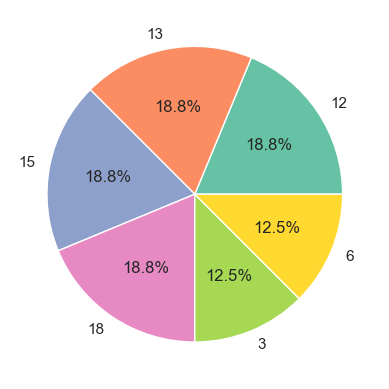

In [32]:
#集計（どの馬が上位人気でよく買われているか）
race_sp_count = race_sp_table_con.groupby(['馬番', '馬名']).size().reset_index()
race_sp_count.columns = ['馬番', '馬名','count']
race_sp_count['ratio'] = 100 * race_sp_count['count']/ race_sp_count['count'].sum() 
race_sp_count.sort_values(['count'], ascending=False).reset_index()

#40％以上は軸確定
#20％以上は軸・対抗になり得る


#グラフ表示
plt.style.use('default')
sns.set()
sns.set_style('whitegrid')
sns.set_palette('Set2')

x = race_sp_count['馬番']
y = race_sp_count['count']

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.pie(y, labels=x, autopct="%1.1f%%")

plt.show()

###　三連単

In [43]:
race_type = 'b8'

race_st = race_table_uwsnpt(race_id, race_type)
race_st_table = race_st.drop(['人気', '選択', '組み合わせ'], axis = 1)
race_st_table['オッズ'] = pd.to_numeric(race_st_table['オッズ'], errors='coerce')
race_st_table = race_st_table[race_st_table['オッズ'] != 'オッズ']

#race_st_table

In [44]:
#対象を180倍以下にする
race_st_table_fil = race_st_table[race_s_table['オッズ']<=180]

#１着
race_st_table_1 = race_st_table_fil.drop(['2頭目', '2頭目.1', '3頭目', '3頭目.1'], axis = 1)
race_st_table_1 = race_st_table_1.rename(columns={'1頭目': '馬番', '1頭目.1': '馬名'})
###集計（どの馬が上位人気でよく買われているか）
race_st_count_1 = race_st_table_1.groupby(['馬番', '馬名']).size().reset_index()
race_st_count_1.columns = ['馬番', '馬名','count']
race_st_count_1['ratio'] = 100 * race_st_count_1['count']/ race_st_count_1['count'].sum() 
race_st_count_1 = race_st_count_1.sort_values(['count'], ascending=False).reset_index()
print(race_st_count_1)


#２着
race_st_table_2 = race_st_table_fil.drop(['1頭目', '1頭目.1', '3頭目', '3頭目.1'], axis = 1)
race_st_table_2 = race_st_table_2.rename(columns={'2頭目': '馬番', '2頭目.1': '馬名'})
###集計（どの馬が上位人気でよく買われているか）
race_st_count_2 = race_st_table_2.groupby(['馬番', '馬名']).size().reset_index()
race_st_count_2.columns = ['馬番', '馬名','count']
race_st_count_2['ratio'] = 100 * race_st_count_2['count']/ race_st_count_2['count'].sum() 
race_st_count_2 = race_st_count_2.sort_values(['count'], ascending=False).reset_index()
print(race_st_count_2)


#３着
race_st_table_3 = race_st_table_fil.drop(['1頭目', '1頭目.1', '2頭目', '2頭目.1'], axis = 1)
race_st_table_3 = race_st_table_3.rename(columns={'3頭目': '馬番', '3頭目.1': '馬名'})
###集計（どの馬が上位人気でよく買われているか）
race_st_count_3 = race_st_table_3.groupby(['馬番', '馬名']).size().reset_index()
race_st_count_3.columns = ['馬番', '馬名','count']
race_st_count_3['ratio'] = 100 * race_st_count_3['count']/ race_st_count_3['count'].sum() 
race_st_count_3 = race_st_count_3.sort_values(['count'], ascending=False).reset_index()
print(race_st_count_3)


#race_s_table_con

   index  馬番       馬名  count      ratio
0      0  12  ダノンベルーガ     18  32.727273
1      1  13   ドウデュース     15  27.272727
2      3  18  イクイノックス     14  25.454545
3      2  15    ジオグリフ      8  14.545455
   index  馬番         馬名  count      ratio
0      3  18    イクイノックス     14  25.454545
1      2  15      ジオグリフ     12  21.818182
2      0  12    ダノンベルーガ     11  20.000000
3      1  13     ドウデュース     10  18.181818
4      5   6      プラダリア      5   9.090909
5      4   3  アスクビクターモア      3   5.454545
   index  馬番         馬名  count      ratio
0      5   3  アスクビクターモア     10  18.181818
1      6   6      プラダリア     10  18.181818
2      0  12    ダノンベルーガ      9  16.363636
3      4  18    イクイノックス      9  16.363636
4      1  13     ドウデュース      8  14.545455
5      2  15      ジオグリフ      6  10.909091
6      3  16   キラーアビリティ      2   3.636364
7      7   7    オニャンコポン      1   1.818182


,index,馬番,馬名,count,ratio
0,0,12,ダノンベルーガ,18,32.727273
1,1,13,ドウデュース,15,27.272727
2,3,18,イクイノックス,14,25.454545
3,2,15,ジオグリフ,8,14.545455
